In [ ]:
!wget https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_male_bmx_2020.csv
!wget https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_female_bmx_2020.csv

--2026-04-12 17:04:37--  https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_male_bmx_2020.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 144073 (141K) [text/plain]
Saving to: ‘nhanes_adult_male_bmx_2020.csv’

nhanes_adult_male_b 100%[===================>] 140.70K  --.-KB/s    in 0.003s  

2026-04-12 17:04:37 (48.7 MB/s) - ‘nhanes_adult_male_bmx_2020.csv’ saved [144073/144073]

--2026-04-12 17:04:37--  https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_female_bmx_2020.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected

The purpose is to download the dataset and as the result it will be downloaded successfully

In [ ]:
import numpy as np

male = np.genfromtxt('nhanes_adult_male_bmx_2020.csv', delimiter=',', skip_header=1)
female = np.genfromtxt('nhanes_adult_female_bmx_2020.csv', delimiter=',', skip_header=1)

print("Male shape:", male.shape)
print("Female shape:", female.shape)

Male shape: (4082, 7)
Female shape: (4222, 7)


This steps showed that the data sets are loaded successfully

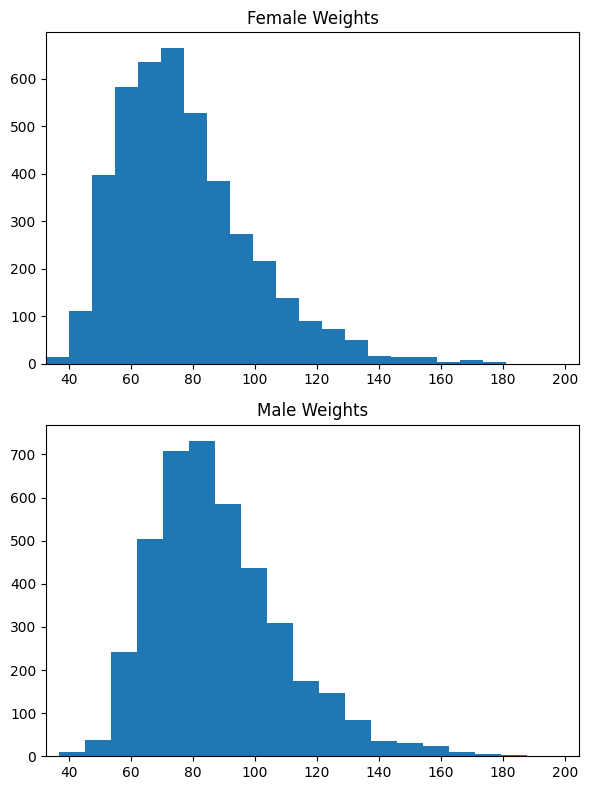

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

female_weights = female[:, 0]
male_weights = male[:, 0]

# Use np.nanmin and np.nanmax to ignore NaN values when calculating min/max
min_w = min(np.nanmin(female_weights), np.nanmin(male_weights))
max_w = max(np.nanmax(female_weights), np.nanmax(male_weights))

plt.figure(figsize=(6,8))

plt.subplot(2,1,1)
plt.hist(female_weights, bins=20)
plt.title("Female Weights")
plt.xlim(min_w, max_w)

plt.subplot(2,1,2)
plt.hist(male_weights, bins=20)
plt.title("Male Weights")
plt.xlim(min_w, max_w)

plt.tight_layout()
plt.show()

The purpose is to visualize the distrubution of weights using the histograms.
As the result, the histograms showed that the male weights are higher than female weights.

In [ ]:
female_weights = female[:, 0]
male_weights = male[:, 0]

female_weights = female_weights[~np.isnan(female_weights)]
male_weights = male_weights[~np.isnan(male_weights)]

print(female_weights[:5])
print(male_weights[:5])

[97.1 91.1 73.  61.7 55.4]
[ 98.8  74.3 103.7  86.   99.4]


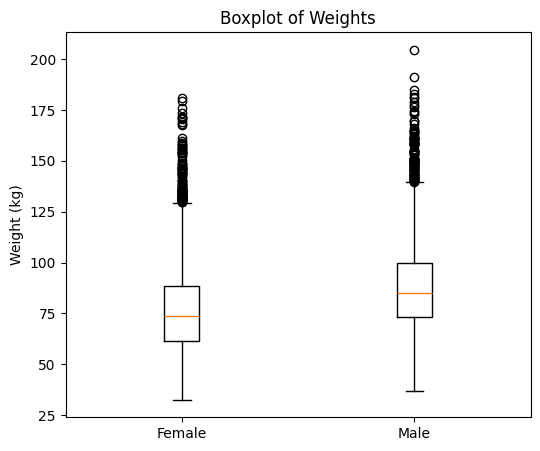

In [ ]:
plt.figure(figsize=(6,5))

plt.boxplot([female_weights, male_weights], tick_labels=["Female", "Male"])

plt.title("Boxplot of Weights")
plt.ylabel("Weight (kg)")

plt.show()

The boxplot shows that male weights have a higher median compared to female weights. The spread of male weights is also wider, indicating greater variability. Additionally, both groups contain outliers, but males show more extreme values.

In [ ]:
print("Female Mean:", np.mean(female_weights))
print("Male Mean:", np.mean(male_weights))

print("Female Std Dev:", np.std(female_weights))
print("Male Std Dev:", np.std(male_weights))

Female Mean: 77.40379057095475
Male Mean: 88.36454300416565
Female Std Dev: 21.54250829019315
Male Std Dev: 21.418936717962495


The mean weight of males is higher than females. The standard deviation of male weights is also higher, indicating that male weights are more spread out compared to female weights.

In [ ]:
height_m = female[:,1] / 100
bmi = female[:,0] / (height_m ** 2)

female = np.column_stack((female, bmi))

print(female.shape)

(4222, 8)


BMI values were successfully computed and appended as the 8th column in the dataset.

In [ ]:
zfemale = (female - np.nanmean(female, axis=0)) / np.nanstd(female, axis=0)

The data is transformed such that each variable has mean 0 and standard deviation 1.

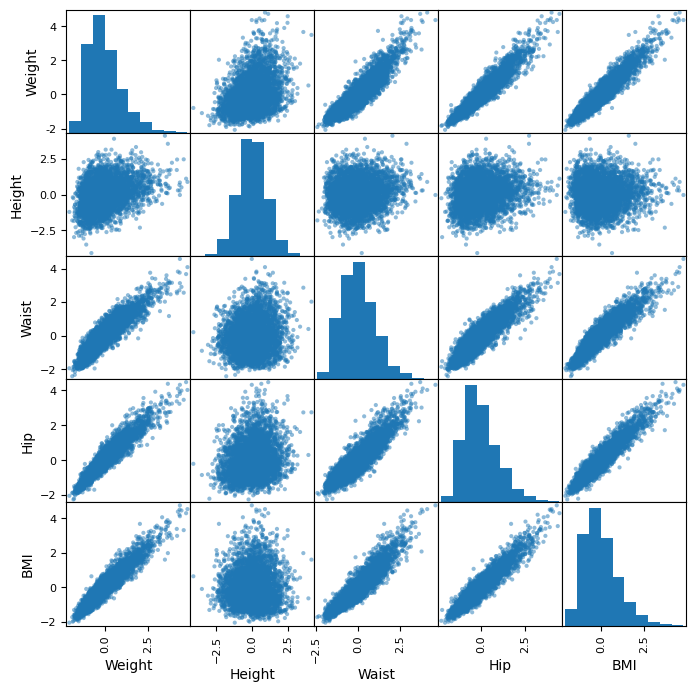

Pearson Correlation:
           Weight    Height     Waist       Hip       BMI
Weight  1.000000  0.345496  0.904550  0.946553  0.945900
Height  0.345496  1.000000  0.126547  0.202895  0.033077
Waist   0.904550  0.126547  1.000000  0.897407  0.921198
Hip     0.946553  0.202895  0.897407  1.000000  0.944199
BMI     0.945900  0.033077  0.921198  0.944199  1.000000
Spearman Correlation:
           Weight    Height     Waist       Hip       BMI
Weight  1.000000  0.338860  0.900169  0.946634  0.937999
Height  0.338860  1.000000  0.108587  0.205405  0.019897
Waist   0.900169  0.108587  1.000000  0.888037  0.923114
Hip     0.946634  0.205405  0.888037  1.000000  0.934196
BMI     0.937999  0.019897  0.923114  0.934196  1.000000


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
mean_female = np.nanmean(female, axis=0)
std_female = np.nanstd(female, axis=0)
zfemale_corrected = (female - mean_female) / std_female

df = pd.DataFrame(zfemale_corrected[:, [0,1,6,5,7]],
columns=["Weight","Height","Waist","Hip","BMI"])

df_cleaned = df.dropna()

if not df_cleaned.empty:
    pd.plotting.scatter_matrix(df_cleaned, figsize=(8,8))
    plt.show()
    print("Pearson Correlation:\n", df_cleaned.corr(method='pearson'))
    print("Spearman Correlation:\n", df_cleaned.corr(method='spearman'))
else:
    print("DataFrame is empty after dropping NaN values, cannot plot scatter matrix or correlations.")

Strong positive correlation is observed between weight and BMI. Waist and hip measurements are also positively correlated.

In [ ]:
male_ratio1 = male[:,6] / male[:,1]
male_ratio2 = male[:,6] / male[:,5]

female_ratio1 = female[:,6] / female[:,1]
female_ratio2 = female[:,6] / female[:,5]

male = np.column_stack((male, male_ratio1, male_ratio2))
female = np.column_stack((female, female_ratio1, female_ratio2))

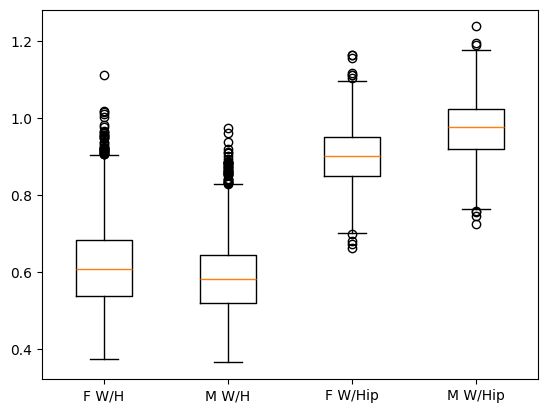

In [ ]:
female_ratio1_clean = female_ratio1[~np.isnan(female_ratio1)]
male_ratio1_clean = male_ratio1[~np.isnan(male_ratio1)]
female_ratio2_clean = female_ratio2[~np.isnan(female_ratio2)]
male_ratio2_clean = male_ratio2[~np.isnan(male_ratio2)]

plt.boxplot([female_ratio1_clean, male_ratio1_clean, female_ratio2_clean, male_ratio2_clean],
tick_labels=["F W/H","M W/H","F W/Hip","M W/Hip"])
plt.show()

The ratios show differences in body fat distribution between males and females.

In [ ]:
bmi_values = female[:, 7]
valid_bmi_mask = ~np.isnan(bmi_values)
clean_bmi_values = bmi_values[valid_bmi_mask]
clean_zfemale_rows = zfemale[valid_bmi_mask]
sorted_indices_of_clean_bmi = np.argsort(clean_bmi_values)
lowest_bmi_clean_indices = sorted_indices_of_clean_bmi[:5]
highest_bmi_clean_indices = sorted_indices_of_clean_bmi[-5:]

print("Lowest BMI (standardized values):")
print(clean_zfemale_rows[lowest_bmi_clean_indices])
print("\nHighest BMI (standardized values):")
print(clean_zfemale_rows[highest_bmi_clean_indices])

Lowest BMI (standardized values):
[[-2.07978523 -1.22299143 -1.5478402  -1.16905675 -2.1947611  -2.0405496
  -1.94212128 -2.05024028 -1.74538177 -0.87170621]
 [-1.88017988 -0.18929313 -1.71835247  0.38637892 -2.4443617  -1.85491922
  -2.05708015 -1.99487987 -2.04369083 -1.63576925]
 [-1.53667299  1.80730222  0.62619127  0.5730312  -2.26607556 -1.6756899
  -1.7064556  -1.97088383 -2.01516552 -0.98358297]
 [-1.843044   -0.26009438 -0.22637009  0.51081377 -2.30173278 -2.25178417
  -1.85590213 -1.94177591 -1.82748279 -0.07452609]
 [-1.61094475  0.88688592 -0.09848588  0.47970506 -2.21258971 -1.82931504
  -1.71220354 -1.89319577 -1.87684602 -0.65912886]]

Highest BMI (standardized values):
[[ 4.2472403   0.29215539  1.86240524 -0.98240447  2.3693641   4.10445598
   3.81731803  4.39649161  3.71218972  0.71350043]
 [ 4.45612963  0.50455915  1.69189297 -1.13794804  3.34993787  3.98283607
   2.90339503  4.46201122  2.72686922 -0.42446668]
 [ 4.34936397  0.27799514  2.84285081  1.94181459  4.366

As the result ,Individuals with low BMI are lean, while those with high BMI indicate overweight or obesity.

1.The dataset used in this project was taken from the National Health and Nutrition Examination Survey (NHANES), which is conducted by the Centers for Disease Control and Prevention (CDC).
2.The analysis and visualizations were performed using Python libraries such as NumPy, Matplotlib, and Pandas, which are commonly used for data analysis and scientific computing.
3.The concept of Body Mass Index (BMI) and its interpretation were referred from guidelines provided by the World Health Organization (WHO).
4.The AI tools like chatgpt and gemni was used t refer the code.